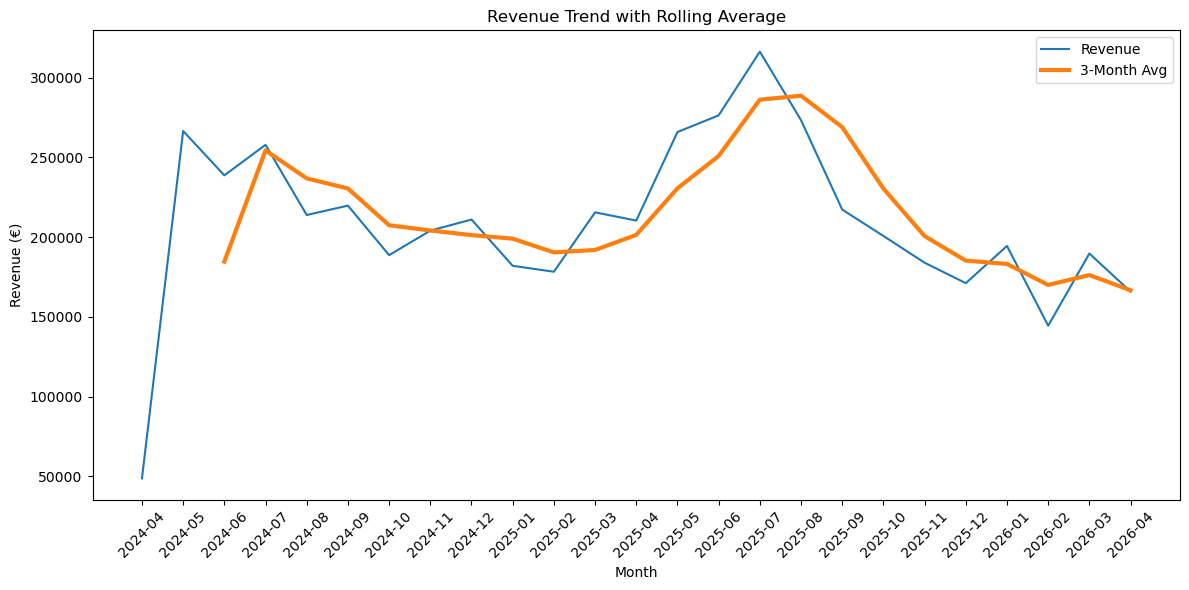

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

conn = sqlite3.connect("database/nordicspace.db")
df = pd.read_sql("SELECT * FROM bookings_raw", conn)
conn.close()

df["start_date"] = pd.to_datetime(df["start_date"])
df["month_year"] = df["start_date"].dt.to_period("M").astype(str)

monthly = df.groupby("month_year")["total_revenue"].sum().reset_index()

# Rolling average
monthly["rolling_avg"] = monthly["total_revenue"].rolling(3).mean()

plt.figure(figsize=(12,6))
plt.plot(monthly["month_year"], monthly["total_revenue"], label="Revenue")
plt.plot(monthly["month_year"], monthly["rolling_avg"], linewidth=3, label="3-Month Avg")

plt.title("Revenue Trend with Rolling Average")
plt.xlabel("Month")
plt.ylabel("Revenue (€)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.savefig("charts/trend_revenue_rolling.png")
plt.show()

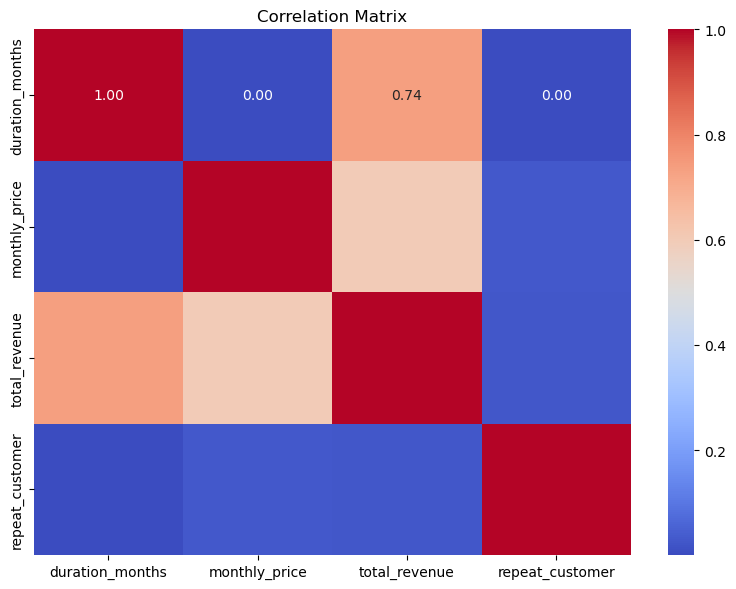

In [3]:

import seaborn as sns


conn = sqlite3.connect("database/nordicspace.db")
df = pd.read_sql("SELECT * FROM bookings_raw", conn)
conn.close()

# Numeric columns only
corr_df = df[[
    "duration_months",
    "monthly_price",
    "total_revenue",
    "repeat_customer"
]]

corr = corr_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix")
plt.tight_layout()

plt.savefig("charts/correlation_heatmap.png")
plt.show()

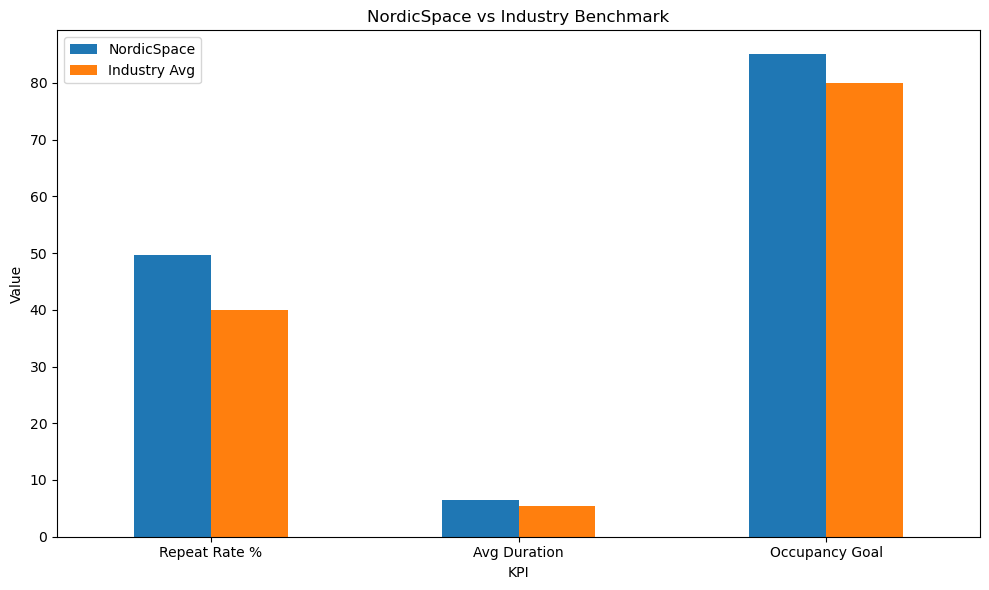

In [4]:


benchmark = pd.DataFrame({
    "KPI": ["Repeat Rate %", "Avg Duration", "Occupancy Goal"],
    "NordicSpace": [49.6, 6.5, 85],
    "Industry Avg": [40, 5.5, 80]
})

benchmark.set_index("KPI").plot(kind="bar", figsize=(10,6))

plt.title("NordicSpace vs Industry Benchmark")
plt.ylabel("Value")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("charts/benchmark_comparison.png")
plt.show()